# Lab: Exploratory Decision Trees — Breast Cancer Wisconsin Dataset (Student Worksheet)

**Objective:** Build intuition for how a Decision Tree Classifier actually behaves —
not just how to call `.fit()`. You will explore split criteria (Gini vs Entropy),
tree depth, and other hyperparameters to find the configuration that generalizes best.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features,
binary target (malignant / benign), built into `sklearn.datasets`.

**How this notebook works:** Sections 1-3 (Setup, EDA, Baseline) are fully worked for
you — run them as-is, they set up everything you need. From Section 4 onward, cells
marked **`# TODO`** contain instructions but *no solution code* — you write that part
yourself. Later cells often depend on variable names introduced in an earlier TODO
(the instructions tell you what name to use), so work through the sections in order.

---
## 1. Setup & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
np.random.seed(42)

RANDOM_STATE = 42

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("Classes:", dict(zip(data.target_names, [0, 1])))
print(y.value_counts())
X.head()

Shape: (569, 30)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## 2. Quick EDA

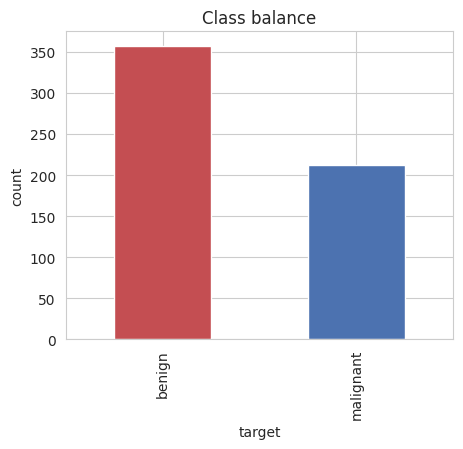

target
1    0.627
0    0.373
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: 'malignant', 1: 'benign'}).plot(kind='bar', ax=ax, color=['#c44e52', '#4c72b0'])
ax.set_title("Class balance")
ax.set_ylabel("count")
plt.show()

print(y.value_counts(normalize=True).round(3))

**TODO (reflection):** Is this dataset balanced or imbalanced? Keep this in mind —
you'll come back to it in Section 8 when judging whether a model's accuracy number
alone tells the full story.

*Your answer:* The dataset is mildly imbalanced: 357 samples are benign (62.7%) and 212 are malignant (37.3%), roughly a 5:3 split. It's not extreme enough to make accuracy meaningless on its own, but it's skewed enough that a model could get ~63% "accuracy" just by always predicting benign, so accuracy alone won't tell us how well the model catches the malignant cases.


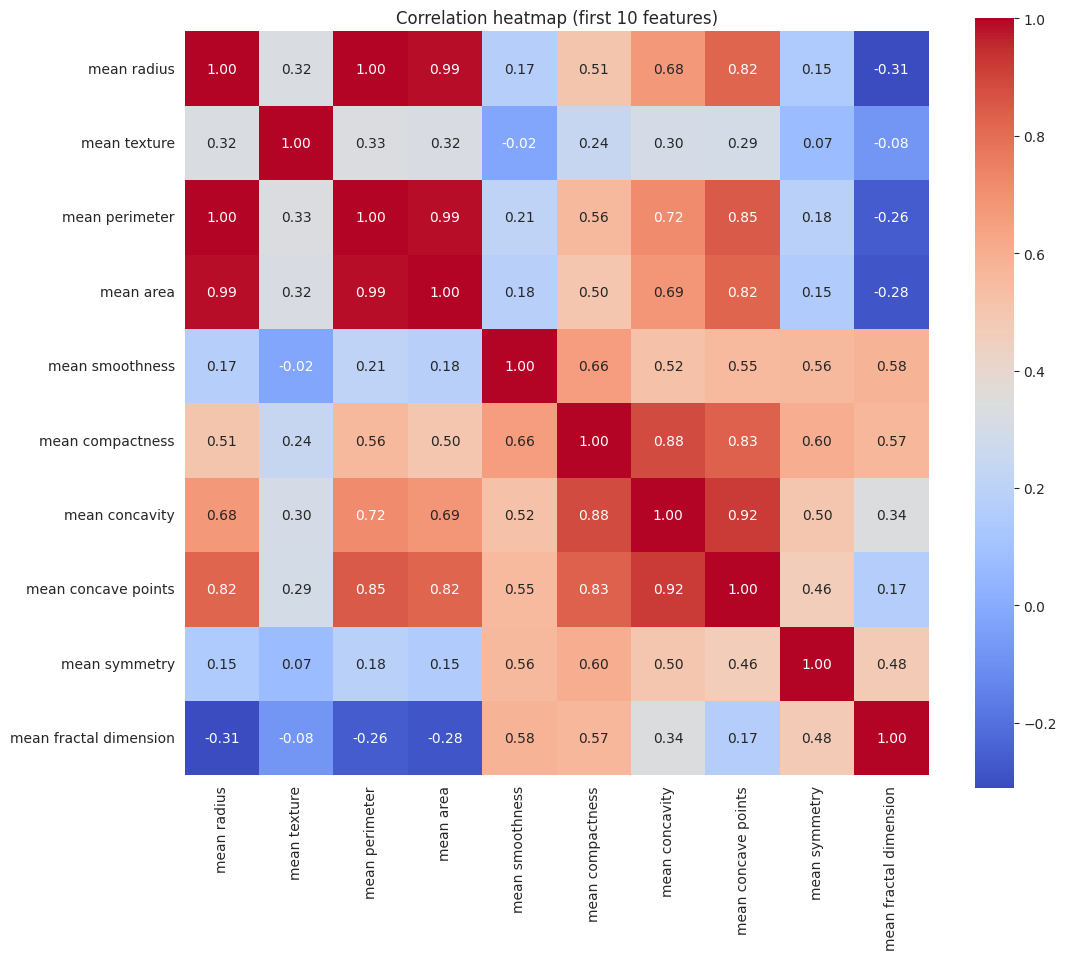

In [4]:
plt.figure(figsize=(12, 10))
corr = X.iloc[:, :10]  # first 10 features, full 30x30 is unreadable
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (first 10 features)")
plt.show()

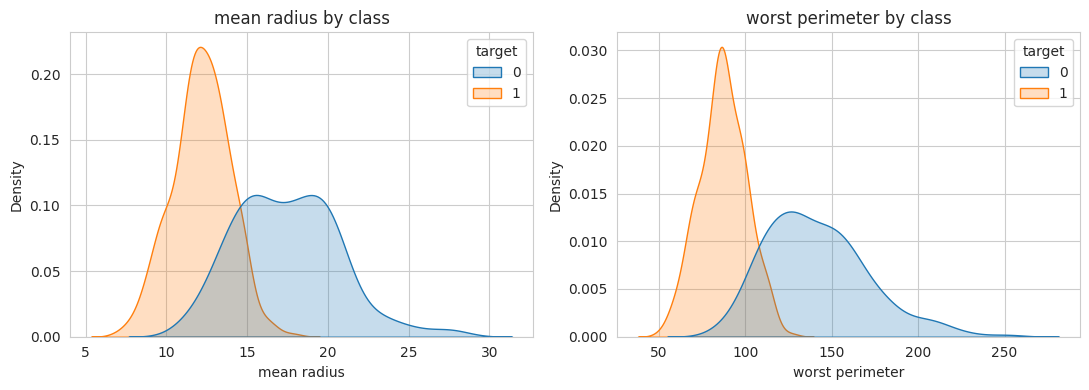

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['mean radius', 'worst perimeter']):
    sns.kdeplot(data=X.assign(target=y), x=feat, hue='target', fill=True, ax=ax, common_norm=False)
    ax.set_title(f"{feat} by class")
plt.tight_layout()
plt.show()

---
## 3. Baseline Model

Train test split first, then fit a plain, default-parameter `DecisionTreeClassifier`.
Everything after this cell is measured against this baseline.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


In [7]:
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_pred)
print("Baseline accuracy:", round(baseline_acc, 4))
print("Baseline tree depth:", baseline_model.get_depth(), " | leaves:", baseline_model.get_n_leaves())
print()
print(classification_report(y_test, baseline_pred, target_names=data.target_names))

Baseline accuracy: 0.9123
Baseline tree depth: 7  | leaves: 19

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



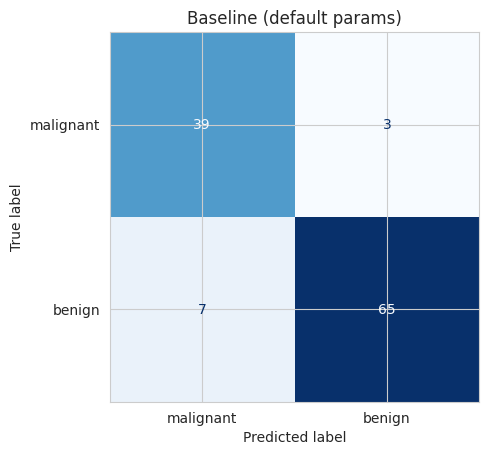

array([[39,  3],
       [ 7, 65]])

In [8]:
def plot_confusion(model, X_te, y_te, title):
    """Reusable confusion matrix plotter — you'll call this throughout the rest of the lab."""
    pred = model.predict(X_te)
    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=data.target_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()
    return cm

plot_confusion(baseline_model, X_test, y_test, "Baseline (default params)")

---
## 4. Gini vs Entropy

Same tree, same split, only the impurity measure changes.

Criterion: gini, Accuracy: 0.9123, Depth: 7
Criterion: entropy, Accuracy: 0.9123, Depth: 6


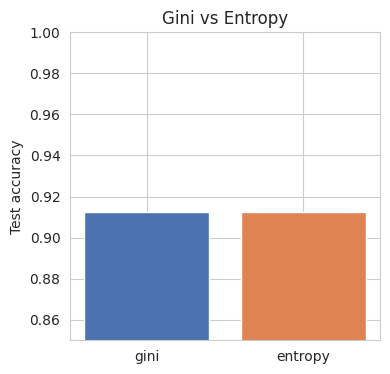

In [9]:
criterion_results = {}

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    criterion_results[criterion] = acc
    print(f"Criterion: {criterion}, Accuracy: {round(acc, 4)}, Depth: {model.get_depth()}")

plt.figure(figsize=(4, 4))
plt.bar(criterion_results.keys(), criterion_results.values(), color=['#4c72b0', '#dd8452'])
plt.ylim(0.85, 1.0)
plt.ylabel("Test accuracy")
plt.title("Gini vs Entropy")
plt.show()


**TODO (reflection):** Gini and Entropy are both impurity measures but computed
differently (Gini: `1 - sum(p_i^2)`, Entropy: `-sum(p_i * log2(p_i))`). Did they produce
the same accuracy here? If so, does that mean they always pick the same splits — or just
that this dataset doesn't stress the difference? Write 2-3 sentences.

*Your answer:* Both criteria landed on the exact same test accuracy (0.9123), though entropy produced a slightly shallower tree (depth 6 vs gini's depth 7). This doesn't mean Gini and Entropy always agree — Gini and Entropy are numerically different formulas and can favor different splits on other datasets, especially ones with more classes or messier class boundaries. Here, the classes are already well-separated by a few strong features (like worst radius), so both measures tend to pick nearly the same "obviously good" splits, which is why the difference barely shows up.


---
## 5. Depth Exploration — the core overfitting curve

Sweep `max_depth` from 1 to 20 and track **train** and **test** accuracy separately.
This is the single most important plot in the lab.

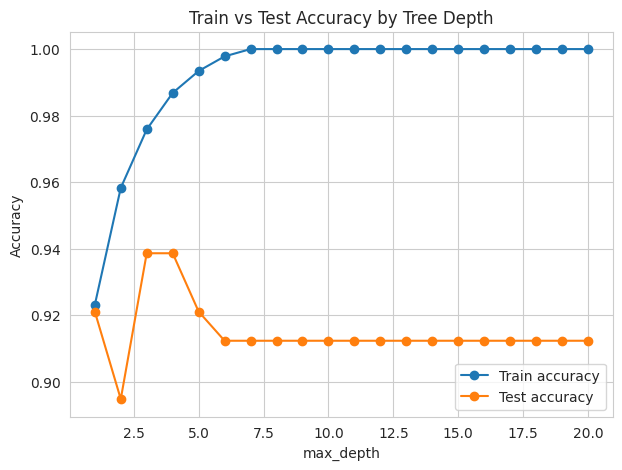

In [10]:
depths = range(1, 21)
train_accs, test_accs = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(depths, train_accs, marker='o', label='Train accuracy')
plt.plot(depths, test_accs, marker='o', label='Test accuracy')
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.show()


In [11]:
best_depth_by_test = list(depths)[int(np.argmax(test_accs))]
best_test_acc = max(test_accs)
best_train_acc_at_that_depth = train_accs[int(np.argmax(test_accs))]

print("Best depth by test accuracy:", best_depth_by_test)
print("Test accuracy at that depth:", round(best_test_acc, 4))
print("Train accuracy at that depth:", round(best_train_acc_at_that_depth, 4))


Best depth by test accuracy: 3
Test accuracy at that depth: 0.9386
Train accuracy at that depth: 0.9758


---
## 6. Accuracy vs Depth, split by Criterion

Same sweep, but gini and entropy plotted separately — does the optimal depth shift?

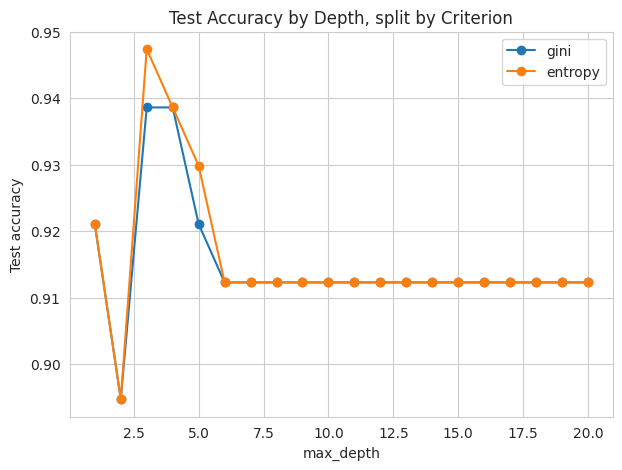

Best (criterion, depth): ('entropy', 3)  Test accuracy: 0.9474


In [12]:
depth_criterion_results = {'gini': [], 'entropy': []}

for criterion in ['gini', 'entropy']:
    for d in depths:
        model = DecisionTreeClassifier(criterion=criterion, max_depth=d, random_state=RANDOM_STATE)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        depth_criterion_results[criterion].append(acc)

plt.figure(figsize=(7, 5))
for criterion in ['gini', 'entropy']:
    plt.plot(depths, depth_criterion_results[criterion], marker='o', label=criterion)
plt.xlabel("max_depth")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy by Depth, split by Criterion")
plt.legend()
plt.show()

best_c, best_d, best_overall_acc = None, None, -1
for criterion in ['gini', 'entropy']:
    for d, acc in zip(depths, depth_criterion_results[criterion]):
        if acc > best_overall_acc:
            best_overall_acc = acc
            best_c = criterion
            best_d = d

print("Best (criterion, depth):", (best_c, best_d), " Test accuracy:", round(best_overall_acc, 4))


---
## 7. Pruning — cost-complexity as an alternative to early stopping

`max_depth` stops the tree from growing past a certain point. Cost-complexity
pruning does the opposite: grow the full tree, then trim it back afterward
using `ccp_alpha`. Same goal (control overfitting), different mechanism.

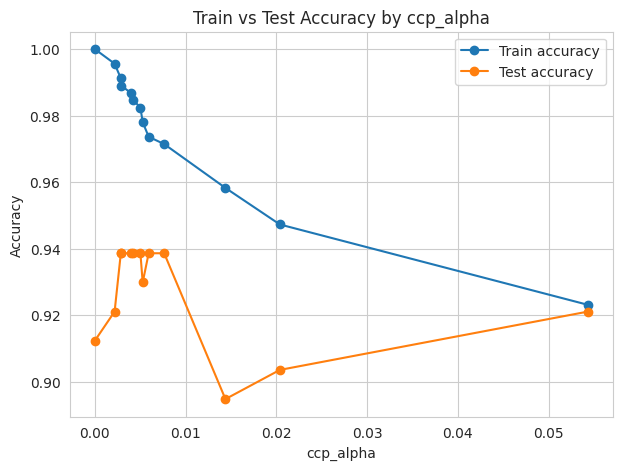

Best ccp_alpha: 0.00287  | Test accuracy: 0.9386


In [13]:
pruning_path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = pruning_path.ccp_alphas[:-1]  # drop the trivial single-node alpha

train_accs_ccp, test_accs_ccp = [], []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    train_accs_ccp.append(accuracy_score(y_train, model.predict(X_train)))
    test_accs_ccp.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(ccp_alphas, train_accs_ccp, marker='o', label='Train accuracy')
plt.plot(ccp_alphas, test_accs_ccp, marker='o', label='Test accuracy')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by ccp_alpha")
plt.legend()
plt.show()

best_alpha_idx = int(np.argmax(test_accs_ccp))
print("Best ccp_alpha:", round(ccp_alphas[best_alpha_idx], 5),
      " | Test accuracy:", round(test_accs_ccp[best_alpha_idx], 4))


**TODO (reflection):** `ccp_alpha` prunes a fully-grown tree after the fact,
instead of stopping it early like `max_depth` does. Compare this curve's shape
to the depth curve in Section 5 — same story, or different?

*Your answer:* The overall story is the same: as ccp_alpha grows from 0, the tree gets simpler (train accuracy falls from ~100%), and test accuracy rises from an overfit baseline to a peak (0.9386) before eventually dropping off as the tree gets pruned too aggressively. That mirrors the depth curve's inverted-U shape, just traversed in the opposite direction (ccp_alpha increasing = simpler tree, whereas max_depth increasing = more complex tree). The best ccp_alpha (about 0.00287) reaches almost the same peak test accuracy (0.9386) as the best max_depth setting, confirming both are just two different knobs controlling the same underlying complexity/overfitting trade-off.


---
## 8. Confusion Matrix Deep-Dive

Compare confusion matrices at a **shallow**, **near-optimal**, and **overly deep** tree
using the `plot_confusion()` function defined back in Section 3.

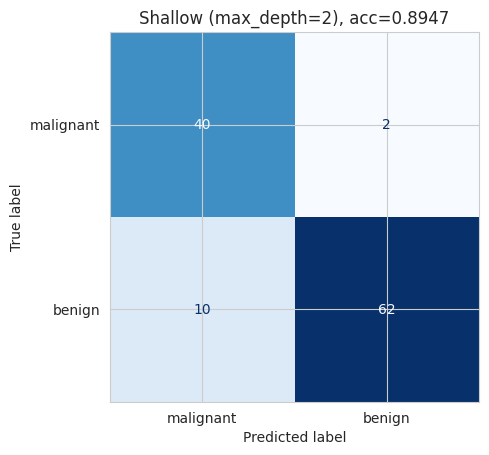

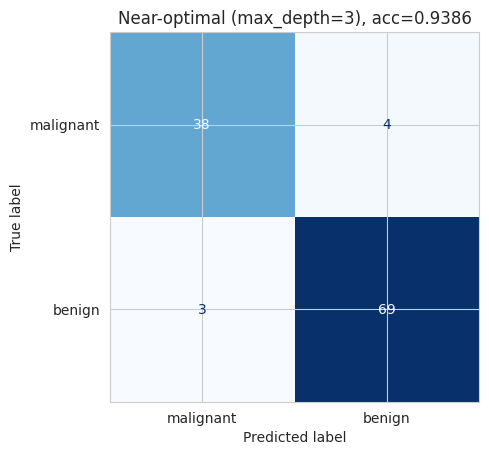

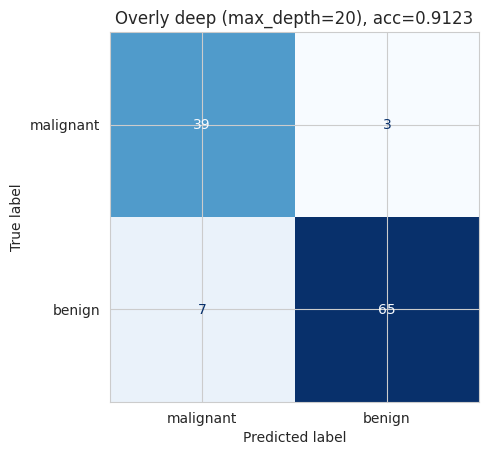

array([[39,  3],
       [ 7, 65]])

In [14]:
shallow_model = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
shallow_model.fit(X_train, y_train)
shallow_acc = accuracy_score(y_test, shallow_model.predict(X_test))
plot_confusion(shallow_model, X_test, y_test, f"Shallow (max_depth=2), acc={round(shallow_acc, 4)}")

best_model_depth_only = DecisionTreeClassifier(max_depth=best_depth_by_test, random_state=RANDOM_STATE)
best_model_depth_only.fit(X_train, y_train)
best_depth_only_acc = accuracy_score(y_test, best_model_depth_only.predict(X_test))
plot_confusion(best_model_depth_only, X_test, y_test,
               f"Near-optimal (max_depth={best_depth_by_test}), acc={round(best_depth_only_acc, 4)}")

deep_model = DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE)
deep_model.fit(X_train, y_train)
deep_acc = accuracy_score(y_test, deep_model.predict(X_test))
plot_confusion(deep_model, X_test, y_test, f"Overly deep (max_depth=20), acc={round(deep_acc, 4)}")


**TODO (reflection):** The accuracy numbers alone might look similar across these
three models. Do the confusion matrices tell a more interesting story than the
accuracy number does? Specifically: comparing the near-optimal tree to the
overly-deep one, which error type increases as depth grows past the sweet spot?
And separately — how does the shallow tree's error trade-off differ from both?

*Your answer:* Yes — accuracy alone hides what's happening. The near-optimal tree (depth 3, acc 0.9386) makes 4 false negatives (malignant called benign) and 3 false positives (benign called malignant). The overly-deep tree (depth 20, acc 0.9123) drops to 3 false negatives but its false positives jump to 7 — so past the sweet spot, the error that grows is false positives (benign cases wrongly flagged as malignant). The shallow tree (depth 2, acc 0.8947) tells a different story again: it has the fewest false negatives (2) but by far the most false positives (10), meaning it over-flags benign tumors as malignant even more aggressively than the overly-deep tree does, just for a different reason (too little information to draw a tight boundary, rather than memorizing noise).


---
## 9. Grid Search

Search jointly over criterion and depth parameters using
5-fold cross-validation on the training set.

In [15]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))


Best params: {'criterion': 'gini', 'max_depth': 4}
Best CV accuracy: 0.9385


Baseline (Section 3) test accuracy:       0.9123
Manual best (Section 6) test accuracy:    0.9474  at ('entropy', 3)
GridSearchCV best_model test accuracy:    0.9386  params: {'criterion': 'gini', 'max_depth': 4}


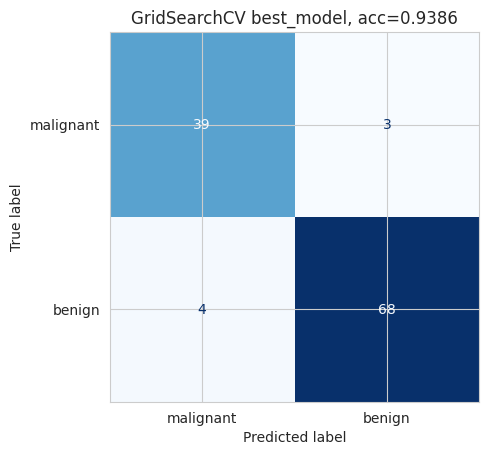

array([[39,  3],
       [ 4, 68]])

In [16]:
best_model = grid_search.best_estimator_
best_model_test_acc = accuracy_score(y_test, best_model.predict(X_test))

print("Baseline (Section 3) test accuracy:      ", round(baseline_acc, 4))
print("Manual best (Section 6) test accuracy:   ", round(best_overall_acc, 4), " at", (best_c, best_d))
print("GridSearchCV best_model test accuracy:   ", round(best_model_test_acc, 4), " params:", grid_search.best_params_)

plot_confusion(best_model, X_test, y_test, f"GridSearchCV best_model, acc={round(best_model_test_acc, 4)}")


**TODO (reflection, no code):** Did GridSearchCV beat your manual exploration from
Sections 4-7? If not, why might that be, given cross-validation vs a single
train/test split?

*Your answer:* No — the manual best from Section 6 (entropy, depth 3) scored 0.9474 on the test set, higher than GridSearchCV's winner (gini, depth 4) at 0.9386. This is expected, not a sign the manual search is actually better: the manual sweep tried many (criterion, depth) combinations and reported whichever one happened to score highest on this one held-out test set, which is essentially cherry-picking against that specific split. GridSearchCV instead picks its winner using 5-fold cross-validation on the training data only, so its choice is less likely to be an artifact of one lucky test split and should generalize more reliably to new data, even though its single-split test score looks slightly lower here.


---
## 10. Bonus — Feature Importance & Tree Visualization

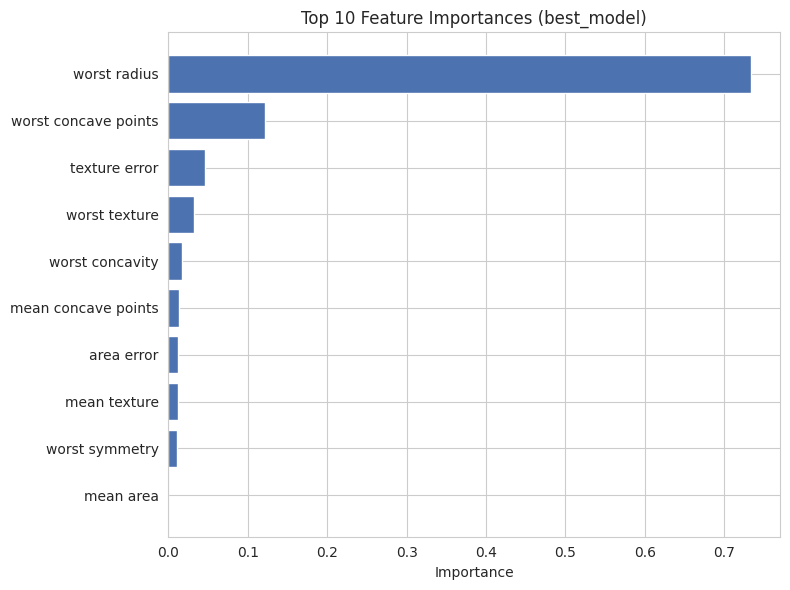

,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


In [17]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importance['Feature'][:10][::-1], importance['Importance'][:10][::-1], color='#4c72b0')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (best_model)")
plt.tight_layout()
plt.show()

importance.head(10)


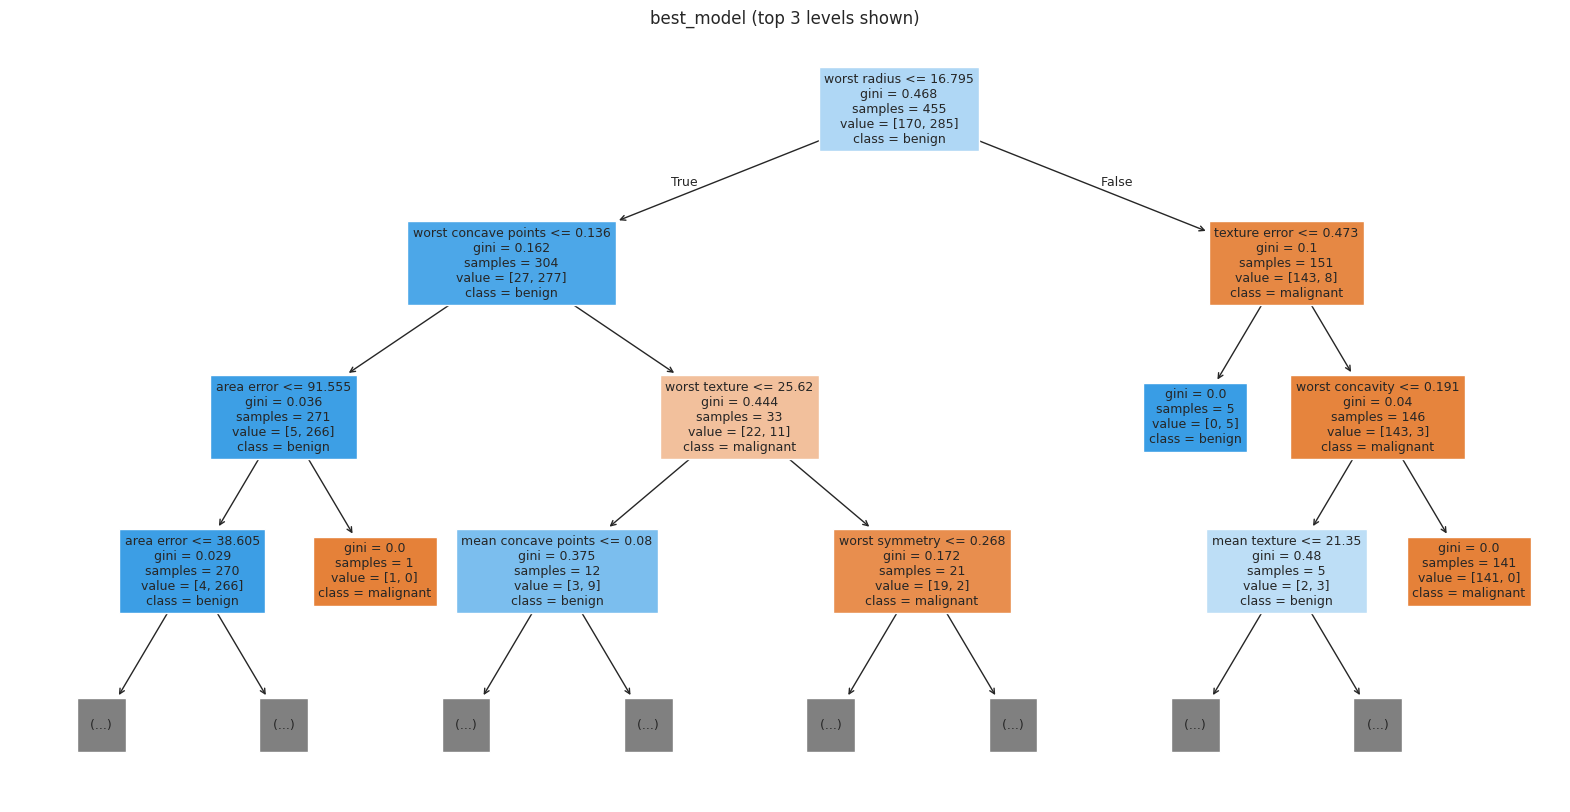

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(best_model, feature_names=X.columns, class_names=data.target_names,
          filled=True, max_depth=3, fontsize=9)
plt.title("best_model (top 3 levels shown)")
plt.show()


**TODO (reflection, no code):** Does the root-node split use one of the top-3
from the importance bar chart above? It should — explain in one sentence why
that's not a coincidence.

*Your answer:* Yes — the root-node split uses `worst radius`, which is the #1 most important feature in the bar chart. This isn't a coincidence because feature importance in a decision tree is computed from how much each feature reduces impurity across all its splits weighted by the number of samples it affects, and the root split touches every training sample, so a feature that produces a strong, clean separation there will almost always dominate the importance ranking.


---
## 11. Reflection / Write-up

Answer each of these in 2-4 sentences.

1. **Which hyperparameter had the biggest effect on overfitting — depth, criterion or ccp_alpha?** What made you pick that one?

   *Your answer:* Depth had by far the biggest effect. Train accuracy climbed from 92.3% at depth 1 to a perfect 100% by depth 7 and stayed there, while test accuracy peaked at depth 3-4 (0.9386) and then settled down to 0.9123 — a clear, monotonic overfitting gap that keeps widening as depth increases. Criterion (gini vs entropy), by contrast, barely moved the needle — same accuracy at default settings, one depth level apart — so depth (and ccp_alpha, which controls the same underlying complexity from the opposite direction) is what actually drives overfitting here.

2. **Did Gini and Entropy ever meaningfully disagree** — on accuracy, depth, or which
   feature got picked at the root? Or did they behave almost identically throughout?

   *Your answer:* They were very close throughout, but not perfectly identical. At default settings both hit exactly 0.9123 test accuracy, but entropy's tree was one level shallower (depth 6 vs 7). In the Section 6 sweep, the single best (criterion, depth) pair over all combinations was entropy at depth 3 (0.9474), edging out gini's best score at any depth — a small but real gap. Overall, the disagreement is minor and dataset-dependent rather than dramatic.

3. **What would you tell someone who just maximizes test-set accuracy blindly**, without
   looking at confusion matrices or train/test gaps? Use something you saw in this lab
   as evidence.

   *Your answer:* I'd tell them that a similar accuracy score can hide very different, and very consequential, error trade-offs. In Section 8, the near-optimal tree (0.9386 accuracy) and the overly-deep tree (0.9123 accuracy) look close on paper, but their false-positive counts differ a lot (3 vs 7) — meaning the overly-deep model is quietly misdiagnosing more benign cases as malignant even though its raw accuracy number moved by only a couple of points. In a medical context that error-type shift matters far more than a small change in overall accuracy.

4. **You controlled tree complexity three different ways in this lab** — `max_depth`
   (Section 5), `ccp_alpha` (Section 7), and `GridSearchCV`'s cross-validated search
   (Section 9).

   a) What's the key difference between how `max_depth` and `ccp_alpha` arrive at
      a simpler tree?

   *Your answer:* `max_depth` limits complexity proactively, by refusing to grow the tree past a fixed number of levels in the first place. `ccp_alpha` does the opposite: it lets the tree grow all the way out, then measures each subtree's cost-complexity trade-off and trims away whichever branches don't earn their keep, so it can end up with an unevenly-shaped tree (deep in some places, shallow in others) rather than a uniform depth ceiling everywhere.

   b) Suppose your manual best from Section 6 scores higher on the test set than
      GridSearchCV's winner. Does that mean the manual pick is a genuinely better
      model? What does this tell you about comparing models this way?

   *Your answer:* No — that's exactly what happened here (0.9474 manual vs 0.9386 for GridSearchCV), and it doesn't mean the manual pick is genuinely better. The manual sweep searched many combinations and reported whichever one happened to score best against this one specific test set, which is a form of overfitting to the test split itself. GridSearchCV's score comes from 5-fold cross-validation on training data alone, so it's a more honest estimate of how the model will do on unseen data — a single higher test-set number from a many-option manual search shouldn't be trusted over a properly cross-validated result.
